<a href="https://colab.research.google.com/github/Cooljoe67/ML_DSAI/blob/main/SML_Day_04_Warmup__Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Warmup: Decision Tree Regularisation Curve

**Estimated time:** 20 min

**Learning objectives**
- Vary one tree hyperparameter at a time.
- Use `validation_curve` to compare training and validation accuracy.
- Choose a reasonable `max_depth` from evidence.


In [6]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
X = cancer.data.copy()
y = cancer.target.copy()

target_names = dict(enumerate(cancer.target_names))
X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#### Exercise 1: Import `DecisionTreeClassifier` and `validation_curve`.


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import validation_curve



##### Hint:


```
from sklearn.tree import ______________________
from sklearn.model_selection import ________________
```
These are both used in today's main notebook.


#### Exercise 2: Create a `param_range` with tree depths from 1 to 10.


In [8]:
import numpy as np
param_range = np.arange(1, 11)



##### Hint:


```
import numpy as np
param_range = np.arange(____, ____)
```
You want the values `1, 2, ..., 10`.


#### Exercise 3: Run `validation_curve` for `max_depth` using accuracy and 5 folds.


In [9]:
train_scores, test_scores = validation_curve(DecisionTreeClassifier(),X,y,param_name="max_depth",param_range=param_range, scoring="accuracy")


##### Hint:


Find the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html)
```
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X,
    y,
    param_name='__________',
    param_range=param_range,
    scoring='accuracy',
    cv=5,
)
```


#### Exam Tip:
`validation_curve` is not a model-selection shortcut by itself; it is a diagnostic plot for **one** hyperparameter.


#### Exercise 4: Calculate the mean training and validation score for each depth.


In [10]:
# Your code here
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

curve = pd.DataFrame({
    'max_depth': param_range,
    'train_accuracy': train_mean,
    'validation_accuracy': test_mean,
})
curve['gap'] = curve['train_accuracy'] - curve['validation_accuracy']
curve

,max_depth,train_accuracy,validation_accuracy,gap
0,1,0.924430,0.899845,0.024586
1,2,0.952112,0.927961,0.024151
2,3,0.973640,0.924375,0.049265
3,4,0.984620,0.917373,0.067247
4,5,0.991213,0.920882,0.070331
5,6,0.996485,0.929669,0.066816
6,7,0.999122,0.922636,0.076486
7,8,0.999560,0.917373,0.082187
8,9,1.000000,0.919112,0.080888
9,10,1.000000,0.915588,0.084412


##### Hint:


```
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
curve = pd.DataFrame({
    'max_depth': param_range,
    'train_accuracy': train_mean,
    'validation_accuracy': test_mean,
})
curve['gap'] = curve['train_accuracy'] - curve['validation_accuracy']
curve
```


#### Exercise 5: Choose a `max_depth` you would try in the main notebook and explain the choice.


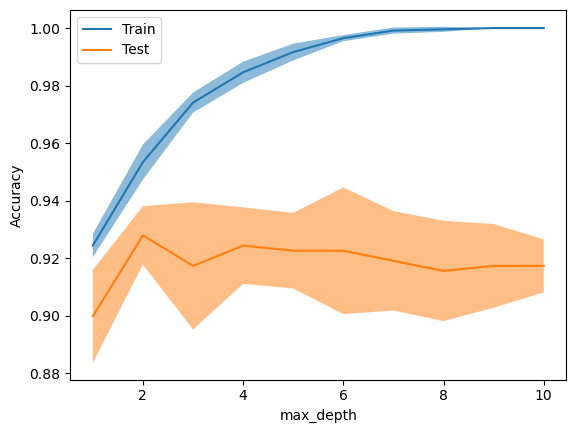

In [14]:
from sklearn.model_selection import ValidationCurveDisplay
display = ValidationCurveDisplay.from_estimator(DecisionTreeClassifier(), X, y, param_name="max_depth", param_range=param_range, scoring="accuracy")


##### Hint:


```
chosen_depth = ____
reason = "I would try this depth because..."
```
Look for good validation accuracy without an unnecessarily large gap.
